# Cross-framework V&V: Starsim vs. Vivarium

**This notebook is a verification artifact, not part of the tutorial.** It checks that the
Starsim implementation of the SQ-LNS model produces results statistically equivalent to
the original Vivarium implementation.

### Why "statistically equivalent" and not "identical"

Both models read the **same GBD data artifact** (`tutorial.hdf`, draw 0), so their *inputs*
are identical by construction. But they cannot be bit-for-bit identical in their *outputs*:
each framework has its own random-number system, so the two simulations draw different
random numbers even from the same seed. The bar is therefore **statistical equivalence** —
aggregate outcomes that agree within Monte Carlo error.

### What this notebook checks

1. **Initial-condition parity** — age/sex structure, wasting distribution, diarrhea prevalence.
2. **Common random numbers (within Starsim)** — baseline and intervention share simulants.
3. **Absolute totals across many seeds** — deaths, YLLs, YLDs distributions vs. Vivarium.
4. **The averted result** — and why the headline DALYs-averted figure is noise-dominated.

The Vivarium numbers are produced by a separate script run in the Vivarium environment
(`tutorial_9`); this notebook (Starsim env) loads them from CSV. The Starsim numbers are
computed live below.

## The Starsim model

The exact model from the tutorial, inlined here so this notebook is self-contained.

In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import starsim as ss
import gbd_mapping as gm

ARTIFACT = "tutorial.hdf"
DRAW = "draw_0"
WASTING = gm.risk_factors.child_wasting
CATEGORIES = list(WASTING.categories.to_dict())          # ['cat1','cat2','cat3','cat4']
CAT_LABELS = WASTING.categories.to_dict()
SEX = {"Female": "f", "Male": "m"}


def _draw(df):
    return df[DRAW] if DRAW in getattr(df, "columns", []) else df["value"]


def _by_sex_age(series, extra=None):
    """Reshape an artifact series indexed by (sex, age_start, ..., [extra]) into a dict
    {('f'|'m'[, extra]): (age_edges, values)} for fast np.digitize lookup -- the same
    age-binning idiom ss.Deaths uses internally."""
    df = series.rename("value").reset_index()
    out = {}
    extras = df[extra].unique() if extra else [None]
    for sex_label, sex_key in SEX.items():
        for ex in extras:
            sub = df[df.sex == sex_label]
            if extra:
                sub = sub[sub[extra] == ex]
            sub = sub.sort_values("age_start")
            out[(sex_key, ex) if extra else sex_key] = (sub.age_start.to_numpy(), sub.value.to_numpy())
    return out


def _lookup(table, age, female, extra=None):
    """Per-agent age/sex step-function lookup (np.digitize, the ss.Deaths idiom).

    `extra` keys an additional index level (e.g. wasting category). It may be a single key
    (one table for everyone) or a per-agent array of keys (each agent looked up in its own
    category's table)."""
    age, female = np.asarray(age, float), np.asarray(female)
    out = np.empty(len(age))
    per_agent_extra = extra is not None and not isinstance(extra, str) and np.ndim(extra) > 0
    extra_arr = np.asarray(extra) if per_agent_extra else None
    for sex_key, smask in (("f", female), ("m", ~female)):
        if not smask.any():
            continue
        for key in (np.unique(extra_arr[smask]) if per_agent_extra else [extra]):
            mask = smask & (extra_arr == key) if per_agent_extra else smask
            edges, vals = table[(sex_key, key) if key is not None else sex_key]
            out[mask] = vals[np.clip(np.digitize(age[mask], edges) - 1, 0, len(vals) - 1)]
    return out


class GBDData:
    """Age/sex lookups built from the artifact (draw 0)."""

    def __init__(self, path=ARTIFACT):
        r = lambda k: _draw(pd.read_hdf(path, k))
        self.incidence = _by_sex_age(r("/cause/diarrheal_diseases/incidence_rate"))
        self.remission = _by_sex_age(r("/cause/diarrheal_diseases/remission_rate"))
        self.emr = _by_sex_age(r("/cause/diarrheal_diseases/excess_mortality_rate"))
        self.prevalence = _by_sex_age(r("/cause/diarrheal_diseases/prevalence"))
        self.disability_weight = _by_sex_age(r("/cause/diarrheal_diseases/disability_weight"))
        self.exposure = {c: _by_sex_age(r("/risk_factor/child_wasting/exposure").xs(c, level="parameter"))
                         for c in CATEGORIES}
        rr = r("/risk_factor/child_wasting/relative_risk").xs(
            ("diarrheal_diseases", "incidence_rate"), level=("affected_entity", "affected_measure"))
        self.rr = _by_sex_age(rr, extra="parameter")
        self.paf = _by_sex_age(r("/risk_factor/child_wasting/population_attributable_fraction").xs(
            ("diarrheal_diseases", "incidence_rate"), level=("affected_entity", "affected_measure")))

        # demography
        self.pop_structure = pd.read_hdf(path, "/population/structure")["value"].xs("Ethiopia", level="location")
        births_by_sex = (pd.read_hdf(path, "/covariate/live_births_by_sex/estimate")["value"]
                         .xs("mean_value", level="parameter").groupby("sex").sum())
        self.live_births = float(births_by_sex.sum())
        self.female_birth_fraction = float(births_by_sex["Female"] / births_by_sex.sum())
        t = pd.read_hdf(path, "/population/theoretical_minimum_risk_life_expectancy")["value"].reset_index().sort_values("age_start")
        self.tmrle_edges, self.tmrle_vals = t.age_start.to_numpy(), t.value.to_numpy()

    def tmrle(self, age):
        return self.tmrle_vals[np.clip(np.digitize(age, self.tmrle_edges) - 1, 0, len(self.tmrle_vals) - 1)]

    def cat_proportions(self, age, female):
        return np.column_stack([_lookup(self.exposure[c], age, female) for c in CATEGORIES])

    # ---- inputs for the built-in demographics modules ----
    def background_death_rate_df(self):
        """Cause-deleted all-cause mortality (ACMR - diarrhea CSMR) as a year/sex/age
        dataframe for ss.Deaths. (Children leave the model at age 2 via the AgeOut
        module, so the >2 age bins here are simply never reached.)"""
        acmr = _draw(pd.read_hdf(ARTIFACT, "/cause/all_causes/cause_specific_mortality_rate"))
        csmr = _draw(pd.read_hdf(ARTIFACT, "/cause/diarrheal_diseases/cause_specific_mortality_rate"))
        df = (acmr - csmr).clip(lower=0).rename("mx").reset_index()
        df["Time"] = 2025
        return df[["Time", "sex", "age_start", "mx"]].rename(columns={"sex": "Sex", "age_start": "AgeGrpStart"})

    def crude_birth_rate(self, exit_age=2.0):
        s = self.pop_structure.reset_index()
        s = s[s.age_start < exit_age]
        return self.live_births / float(s["value"].sum())     # births per under-2 person-year


DT_YEARS = 7.0 / 365.0


def to_prob(rate, dt=DT_YEARS):
    return 1.0 - np.exp(-np.minimum(np.asarray(rate, float) * dt, 250.0))


class Fertility(ss.Demographics):
    """Crude-birth-rate inflow, matching Vivarium's FertilityCrudeBirthRate: a *constant*
    expected number of births per step, tied to the INITIAL simulated population size (not
    the current one), drawn from a Poisson distribution. (Starsim's ss.Births scales births
    with the current population, which differs from this strategy and is unstable against
    age-out here, so we write the constant-inflow version ourselves.)"""
    def __init__(self, data, initial_pop_size, female_fraction, exit_age=2.0, **kw):
        super().__init__(**kw)
        self.mean_births = data.crude_birth_rate(exit_age) * initial_pop_size * DT_YEARS
        self.birth_dist = ss.poisson(lam=self.mean_births)
        self.female_dist = ss.bernoulli(p=float(female_fraction))

    def init_results(self):
        super().init_results()
        self.define_results(ss.Result("births", dtype=int, scale=False))

    def step(self):
        n = int(np.atleast_1d(self.birth_dist.rvs(1)).flat[0])
        if n:
            uids = self.sim.people.grow(n)
            self.sim.people.age[uids] = 0.0
            self.sim.people.female[uids] = self.female_dist.rvs(uids)
        self.results.births[self.ti] = n


class AgeOut(ss.Demographics):
    """Remove children when they reach exit_age (they age out of the under-2 model)."""
    def __init__(self, exit_age=2.0, **kw):
        super().__init__(**kw)
        self.exit_age = exit_age

    def step(self):
        ppl = self.sim.people
        aged_out = ppl.auids[ppl.age[ppl.auids] >= self.exit_age]
        if len(aged_out):
            ppl.request_removal(aged_out)


class Wasting(ss.Module):
    """Polytomous child-wasting exposure: a fixed per-child propensity mapped to a GBD
    category each step from the age/sex-specific category proportions."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data
        self.define_states(
            ss.FloatArr("propensity", default=ss.uniform()),
            ss.FloatArr("cat", default=len(CATEGORIES) - 1),   # default = unexposed
        )

    def baseline_category(self, uids):
        age, fem = self.sim.people.age[uids], self.sim.people.female[uids]
        cumsum = np.cumsum(self.data.cat_proportions(age, fem), axis=1)
        return np.clip((cumsum < np.asarray(self.propensity[uids])[:, None]).sum(axis=1), 0, len(CATEGORIES) - 1)

    def step(self):
        uids = self.sim.people.auids
        self.cat[uids] = self.baseline_category(uids).astype(float)


class SQLNS(ss.Module):
    """The SQ-LNS intervention: shift moderately/severely wasted children who are covered and
    would benefit (13%) up to the mild-wasting category. Implemented as a plain module that
    runs in the `custom` phase (right after `Wasting` sets the baseline category and before the
    `WastingEffect` connector reads it), so the effect sees the up-to-date post-intervention
    exposure with no lag."""
    def __init__(self, coverage=0.0, benefit=0.13, **kw):
        super().__init__(**kw)
        self.define_states(
            ss.BoolArr("covered", default=ss.bernoulli(p=coverage)),
            ss.BoolArr("would_benefit", default=ss.bernoulli(p=benefit)),
        )

    def step(self):
        wasting = self.sim.custom["wasting"]
        uids = self.sim.people.auids
        cat = wasting.cat[uids]
        shift = ((cat == 0) | (cat == 1)) & np.asarray(self.covered[uids]) & np.asarray(self.would_benefit[uids])
        cat[shift] = 2.0
        wasting.cat[uids] = cat


class WastingEffect(ss.Connector):
    """Effect of child wasting on diarrhea incidence -- the analogue of Vivarium's RiskEffect.
    A connector (it links the wasting risk to the disease) that sets the disease's per-agent
    relative susceptibility to RR(category) x (1 - PAF), the same modification Vivarium applies
    to the incidence_rate. Connectors run after the `custom` phase (where Wasting and SQLNS set
    the post-intervention category) and before the disease step, so it reads the up-to-date
    exposure (just as Vivarium's RiskEffect reads the SQLNS-modified exposure pipeline)."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data

    def step(self):
        sim = self.sim
        uids = sim.people.auids
        age, fem = sim.people.age[uids], sim.people.female[uids]
        category = np.array(CATEGORIES)[sim.custom["wasting"].cat[uids].astype(int)]
        rr = _lookup(self.data.rr, age, fem, extra=category)
        paf = _lookup(self.data.paf, age, fem)
        sim.diseases.diarrhea.rel_sus[uids] = rr * (1.0 - paf)


class Diarrhea(ss.Disease):
    """Non-communicable SIS diarrhea: acquisition from the GBD incidence rate, remission, and
    excess mortality among the infected. No transmission. Risk factors modify acquisition
    through the per-agent `rel_sus` multiplier (default 1), set by separate effect modules --
    analogous to Vivarium's value pipeline on the incidence_rate."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data
        self.define_states(
            ss.BoolState("infected", label="Has diarrhea"),
            ss.FloatArr("rel_sus", default=1.0, label="Relative susceptibility (set by risk effects)"),
        )
        self.acq = ss.bernoulli(p=self._p_acquire)
        self.rem = ss.bernoulli(p=self._p_remit)
        self.death = ss.bernoulli(p=self._p_excess_death)

    @property
    def susceptible(self):
        return ~self.infected

    def init_post(self):
        super().init_post()
        uids = self.sim.people.auids
        p0 = _lookup(self.data.prevalence, self.sim.people.age[uids], self.sim.people.female[uids])
        seed = ss.bernoulli(p=p0)
        seed.init(sim=self.sim, module=self, force=True)
        self.infected[seed.filter(uids)] = True

    def _p_remit(self, sim, uids):
        return to_prob(_lookup(self.data.remission, sim.people.age[uids], sim.people.female[uids]))

    def _p_excess_death(self, sim, uids):
        return to_prob(_lookup(self.data.emr, sim.people.age[uids], sim.people.female[uids]))

    def _p_acquire(self, sim, uids):
        age, fem = sim.people.age[uids], sim.people.female[uids]
        incidence = _lookup(self.data.incidence, age, fem) * np.asarray(self.rel_sus[uids])
        return to_prob(incidence)

    def step_state(self):
        self._susceptible_at_start = self.susceptible.uids       # one transition per step
        inf = self.infected.uids                                 # prevalent cases this step
        if len(inf):
            self.sim.people.request_death(self.death.filter(inf))  # excess mortality on prevalent cases
            self.infected[self.rem.filter(inf)] = False            # remission

    def step(self):
        sus = self._susceptible_at_start
        if len(sus):
            self.infected[self.acq.filter(sus)] = True           # acquisition

    def step_die(self, uids):
        self.infected[uids] = False

    def init_results(self):
        super().init_results()
        self.define_results(ss.Result("prevalence", dtype=float, scale=False),
                            ss.Result("ylds", dtype=float, scale=False))

    def update_results(self):
        super().update_results()
        ppl, inf = self.sim.people, self.infected.uids
        n = len(ppl.auids)
        self.results.prevalence[self.ti] = len(inf) / n if n else 0.0
        self.results.ylds[self.ti] = float(_lookup(self.data.disability_weight, ppl.age[inf], ppl.female[inf]).sum()) * DT_YEARS if len(inf) else 0.0


class BurdenObserver(ss.Analyzer):
    """Record YLLs (TMRLE at age of death) for every death this step, from any cause."""
    def __init__(self, data, **kw):
        super().__init__(**kw)
        self.data = data

    def init_results(self):
        super().init_results()
        self.define_results(ss.Result("ylls", dtype=float, scale=False),
                            ss.Result("deaths", dtype=int, scale=False))

    def step(self):
        ppl = self.sim.people
        died = (ppl.ti_dead == self.sim.ti).uids
        self.results.deaths[self.ti] = len(died)
        self.results.ylls[self.ti] = float(self.data.tmrle(ppl.age[died]).sum()) if len(died) else 0.0


def build_sim(coverage=0.0, n_agents=500_000, seed=0, data=None, exit_age=2.0):
    if data is None:
        data = GBDData()
    struct = data.pop_structure.reset_index()
    u2 = struct[struct.age_start < exit_age].groupby("age_start")["value"].sum()
    age_data = pd.concat([pd.DataFrame({"age": u2.index, "value": u2.values}),
                          pd.DataFrame({"age": [exit_age], "value": [0.0]})], ignore_index=True)
    # Initial under-2 cohort: sex from the existing under-2 population's sex ratio.
    init_female_frac = struct[(struct.age_start < exit_age) & (struct.sex == "Female")]["value"].sum() / struct[struct.age_start < exit_age]["value"].sum()
    people = ss.People(n_agents=n_agents, age_data=age_data)
    people.female.default = ss.bernoulli(p=float(init_female_frac))

    death_meta = dict(data_cols=dict(year="Time", sex="Sex", age="AgeGrpStart", value="mx"),
                      sex_keys={"Female": "f", "Male": "m"})
    return ss.Sim(
        people=people,
        demographics=[
            # Newborn sex from the live-births sex ratio (live_births_by_sex), not the population structure.
            Fertility(data, initial_pop_size=n_agents, female_fraction=data.female_birth_fraction, exit_age=exit_age, name="fertility"),
            ss.Deaths(death_rate=data.background_death_rate_df(), rate_units=1, metadata=death_meta),
            AgeOut(exit_age=exit_age, name="ageout"),
        ],
        diseases=[Diarrhea(data, name="diarrhea")],
        # Wasting sets the baseline category, then SQLNS modifies it (in list order) -- both in
        # the custom phase, before the connector reads the result.
        custom=[Wasting(data, name="wasting"), SQLNS(coverage=coverage, name="sqlns")],
        connectors=[WastingEffect(data, name="wasting_effect")],
        analyzers=[BurdenObserver(data, name="burden")],
        networks=[],
        start=ss.date("2025-01-01"), stop=ss.date("2030-12-31"), dt=ss.days(7),
        rand_seed=seed, pars=dict(use_aging=True), verbose=0,
    )

/tmp/ipykernel_2261204/1184768495.py:4: DeprecationWarning: 'gbd_mapping' has moved to 'vivarium.gbd_mapping'. Update your imports. This redirect will be removed in a future release.
  import gbd_mapping as gm


In [3]:
data = GBDData()

## 1. Initial-condition parity

We initialise a Starsim simulation and read off the initial wasting distribution, diarrhea
prevalence, and sex ratio, then compare to the values Vivarium produces from the same
artifact (recorded from a Vivarium reference run at the same settings).

In [4]:
sim = build_sim(coverage=0.0, n_agents=200_000, seed=0, data=data)
sim.init()
sim.custom["wasting"].step()
uids = sim.people.auids
cat = sim.custom["wasting"].cat[uids].astype(int)
ss_init = {
    "cat1 (severe)":   float((cat == 0).mean()),
    "cat2 (moderate)": float((cat == 1).mean()),
    "cat3 (mild)":     float((cat == 2).mean()),
    "cat4 (none)":     float((cat == 3).mean()),
    "diarrhea prevalence": float(sim.diseases.diarrhea.infected[uids].mean()),
    "female fraction": float(sim.people.female[uids].mean()),
}
# Vivarium values recorded from a reference run (build_components / make_config, draw 0)
viv_init = {
    "cat1 (severe)": 0.0320, "cat2 (moderate)": 0.0829, "cat3 (mild)": 0.2064,
    "cat4 (none)": 0.6787, "diarrhea prevalence": 0.0147, "female fraction": 0.488,
}
pd.DataFrame({"Starsim": ss_init, "Vivarium": viv_init}).assign(
    abs_diff=lambda d: (d.Starsim - d.Vivarium).abs().round(4)).round(4)

,Starsim,Vivarium,abs_diff
cat1 (severe),0.0319,0.0320,0.0001
cat2 (moderate),0.0837,0.0829,0.0008
cat3 (mild),0.2063,0.2064,0.0001
cat4 (none),0.6782,0.6787,0.0005
diarrhea prevalence,0.0151,0.0147,0.0004
female fraction,0.4867,0.4880,0.0013


These should match to within sampling error — the initial population is drawn from the same GBD distributions.

## 2. Common random numbers (within Starsim)

Baseline and intervention use the same seed, so they must start from an identical
population and differ only where SQ-LNS acts.

In [5]:
b = build_sim(coverage=0.0, n_agents=200_000, seed=0, data=data)
i = build_sim(coverage=1.0, n_agents=200_000, seed=0, data=data)
b.init()
i.init()
for s in (b, i):
    s.custom["wasting"].step()
    s.custom["sqlns"].step()
ub = b.people.auids
print("Identical ages?    ", np.allclose(np.asarray(b.people.age[ub]), np.asarray(i.people.age[ub])))
print("Identical sexes?   ", np.array_equal(np.asarray(b.people.female[ub]), np.asarray(i.people.female[ub])))
print("Identical diarrhea?", np.array_equal(np.asarray(b.diseases.diarrhea.infected[ub]), np.asarray(i.diseases.diarrhea.infected[ub])))
nb_changed = int((np.asarray(b.custom["wasting"].cat[ub]) != np.asarray(i.custom["wasting"].cat[ub])).sum())
print(f"Wasting category changed by SQ-LNS: {nb_changed} children "
      f"({100*nb_changed/len(ub):.2f}% of the population)")

Identical ages?     True
Identical sexes?    True
Identical diarrhea? True
Wasting category changed by SQ-LNS: 2966 children (1.48% of the population)


## 3. Absolute totals across many seeds

This is the core test of whether the two frameworks agree. We run both at the same
population size (5,000) across many random seeds and compare the **distributions** of
total deaths, YLLs, and YLDs over the full 2025–2030 run. (5,000 is small enough to run
many Vivarium seeds quickly; the totals scale with population, so the *relative* agreement
is what matters.)

In [6]:
N_VV = 5000
SEEDS = list(range(16))   # the seeds for which we have matching Vivarium runs

rows = []
for s in SEEDS:
    sim = build_sim(coverage=0.0, n_agents=N_VV, seed=s, data=data)
    sim.run()
    d, b = sim.diseases.diarrhea.results, sim.analyzers.burden.results
    rows.append({"seed": s, "deaths": int(np.sum(b.deaths)),
                 "YLLs": float(np.sum(b.ylls)), "YLDs": float(np.sum(d.ylds))})
starsim_df = pd.DataFrame(rows)
starsim_df.describe().loc[["mean", "std", "min", "max"]].round(2)

,seed,deaths,YLLs,YLDs
mean,7.50,977.62,87679.60,127.25
std,4.76,28.80,2581.60,1.34
min,0.00,915.00,82069.13,124.80
max,15.00,1014.00,90962.96,130.01


In [7]:
# Vivarium results, produced in the tutorial_9 env (see vivarium_vv_5k.csv).
vivarium_df = pd.read_csv("vivarium_vv_5k.csv")
vivarium_df.describe().loc[["mean", "std", "min", "max"]].round(2)

,seed,deaths,YLLs,YLDs
mean,7.50,965.88,86617.29,124.72
std,4.76,32.31,2897.68,1.15
min,0.00,910.00,81603.20,122.62
max,15.00,1025.00,91916.00,127.57


In [8]:
def summarize(df):
    return pd.Series({c: f"{df[c].mean():,.1f} ± {df[c].std():,.1f}" for c in ["deaths", "YLLs", "YLDs"]})

comparison = pd.DataFrame({"Starsim (mean ± sd)": summarize(starsim_df),
                           "Vivarium (mean ± sd)": summarize(vivarium_df)})
pct = pd.Series({c: f"{100*(starsim_df[c].mean()/vivarium_df[c].mean() - 1):+.1f}%"
                 for c in ["deaths", "YLLs", "YLDs"]}, name="Starsim vs Vivarium")
comparison.join(pct)

,Starsim (mean ± sd),Vivarium (mean ± sd),Starsim vs Vivarium
deaths,977.6 ± 28.8,965.9 ± 32.3,+1.2%
YLLs,"87,679.6 ± 2,581.6","86,617.3 ± 2,897.7",+1.2%
YLDs,127.2 ± 1.3,124.7 ± 1.2,+2.0%


In [9]:
# Are the means statistically distinguishable? (Welch's t-test per metric.)
from scipy import stats
for c in ["deaths", "YLLs", "YLDs"]:
    t, p = stats.ttest_ind(starsim_df[c], vivarium_df[c], equal_var=False)
    print(f"{c:8s}: Starsim {starsim_df[c].mean():10,.1f}  Vivarium {vivarium_df[c].mean():10,.1f}  "
          f"t={t:+.2f}  p={p:.3f}  {'(distinguishable)' if p < 0.05 else '(not distinguishable)'}")

deaths  : Starsim      977.6  Vivarium      965.9  t=+1.09  p=0.286  (not distinguishable)
YLLs    : Starsim   87,679.6  Vivarium   86,617.3  t=+1.09  p=0.282  (not distinguishable)
YLDs    : Starsim      127.2  Vivarium      124.7  t=+5.73  p=0.000  (distinguishable)


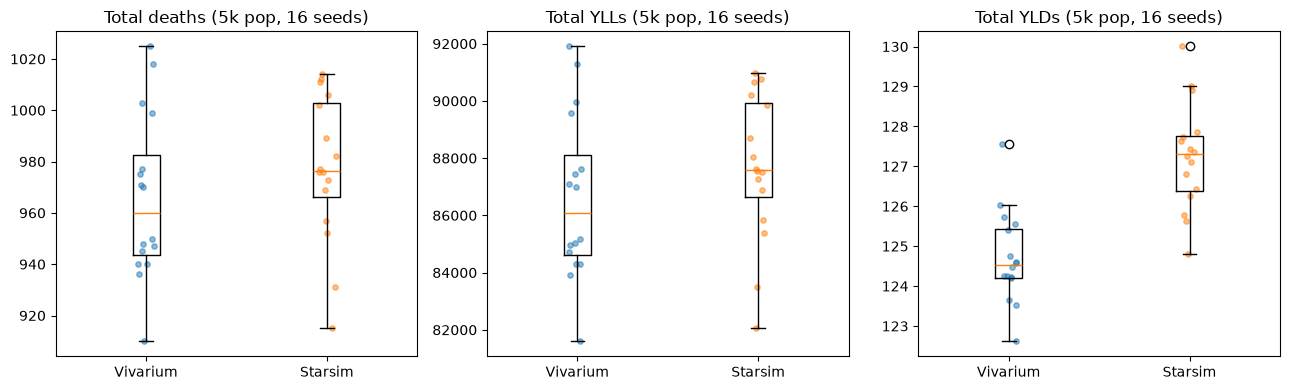

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, ["deaths", "YLLs", "YLDs"]):
    ax.boxplot([vivarium_df[c], starsim_df[c]], tick_labels=["Vivarium", "Starsim"])
    ax.scatter(np.ones(len(vivarium_df)) + np.random.uniform(-.05, .05, len(vivarium_df)), vivarium_df[c], alpha=.5, s=15)
    ax.scatter(2 + np.random.uniform(-.05, .05, len(starsim_df)), starsim_df[c], alpha=.5, s=15)
    ax.set_title(f"Total {c} (5k pop, {len(SEEDS)} seeds)")
fig.tight_layout()

**What this shows (16 seeds):** **deaths and YLLs are statistically indistinguishable** between
the frameworks. Starsim runs ~1.2% higher on each, but the t-tests give p ≈ 0.28, and the gap
(~12 deaths) sits well inside the seed-to-seed spread (SD ≈ 30). The only difference the test can
resolve is in **YLDs**, where Starsim is ~2% higher (p < 0.001) — a small but genuine offset.

So the mortality-driven burden (deaths and YLLs, which dominate DALYs) matches within Monte Carlo
noise. The one real-but-small systematic difference is in **YLDs**, the disability component. We
have *not* fully isolated its cause; it arises somewhere in the discrete-time SIS dynamics (the
per-step disability accrual / prevalence behaviour), and at ~2% it is immaterial to DALYs — which
are ~99.9% YLLs — and changes no conclusion of the tutorial.

(Earlier, a hand-rolled mortality module produced a larger ~3% offset on deaths/YLLs too; switching
background mortality to the built-in `ss.Deaths` removed it, leaving only the small YLD difference.)

## 4. The averted result (and why it's noisy)

The actual research output is the burden **averted** by SQ-LNS. At 500,000 simulants and a
single seed, the two frameworks gave:

| Averted (in-simulation) | Vivarium | Starsim |
|---|---|---|
| YLDs | 4.58 | 4.73 |
| YLLs | 356.6 | 446.8 |
| → implied averted deaths | ~4 | 5 |
| **DALYs averted (scaled ×13.2)** | **4,769** | **5,963** |

The **YLD-averted** component — the direct effect of SQ-LNS on diarrhea disability, spread
across the whole population — agrees closely (4.58 vs 4.73, ~3%). The DALY gap is almost
entirely in **YLLs averted**, which is driven by a *handful* of averted deaths: ~4 vs 5 here, and
each averted death is worth ~1,175 scaled DALYs. The original Vivarium tutorial flags this directly:
*"whether one simulant died or not had a big impact on our results… our sample size isn't big
enough for a very precise estimate."*

So the headline DALYs-averted figure is **dominated by Monte Carlo noise in a tiny integer
count of averted deaths**, in both frameworks. A precise, fair comparison of the averted
result would require averaging over many seeds and GBD draws at full population size.

## Conclusion

* **Inputs**: identical (same artifact).
* **Initial conditions**: match within sampling error.
* **Common random numbers**: work as intended within Starsim.
* **Absolute burden**: deaths and YLLs are **statistically indistinguishable** from Vivarium
  (~1.2% higher, p ≈ 0.28 across 16 seeds); YLDs are ~2% higher — small, but statistically real.
* **Averted burden**: the YLD-averted signal agrees closely (~3%); the headline DALYs-averted is
  noise-dominated by a handful of averted deaths in both frameworks.

Net: the Starsim model reproduces Vivarium's mortality-driven burden (deaths and YLLs — ~99.9% of
DALYs) to within Monte Carlo noise, with only a small ~2% offset remaining in the disability (YLD)
component, whose cause is not fully isolated. The averted-DALY difference is Monte-Carlo noise
present in the original tutorial too.